In [1]:
import tensorflow as tf

In [2]:
print(tf.__version__) #versió
print(tf.config.list_physical_devices('GPU'))

2.21.0
[]


In [3]:
!nvidia-smi

"nvidia-smi" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('Brain_GSE50161.csv')
df

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,834,ependymoma,12.498150,7.604868,6.880934,9.027128,4.176175,7.224920,6.085942,6.835999,...,9.979005,9.926470,12.719785,12.777792,5.403657,4.870548,4.047380,3.721936,4.516434,4.749940
1,835,ependymoma,13.067436,7.998090,7.209076,9.723322,4.826126,7.539381,6.250962,8.012549,...,11.924749,11.215930,13.605662,13.401342,5.224555,4.895315,3.786437,3.564481,4.430891,4.491416
2,836,ependymoma,13.068179,8.573674,8.647684,9.613002,4.396581,7.813101,6.007746,7.178156,...,12.154405,11.532460,13.764593,13.477800,5.303565,5.052184,4.005343,3.595382,4.563494,4.668827
3,837,ependymoma,12.456040,9.098977,6.628784,8.517677,4.154847,8.361843,6.596064,6.347285,...,11.969072,11.288801,13.600828,13.379029,4.953429,4.708371,3.892318,3.759429,4.748381,4.521275
4,838,ependymoma,12.699958,8.800721,11.556188,9.166309,4.165891,7.923826,6.212754,6.866387,...,11.411701,11.169317,13.751442,13.803646,4.892677,4.773806,3.796856,3.577544,4.504385,4.541450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,959,pilocytic_astrocytoma,12.658228,8.843270,7.672655,9.125912,5.495477,8.603892,7.747514,5.828978,...,13.170441,12.676080,14.124837,13.996436,4.913579,4.399176,3.878855,3.680103,4.726784,4.564637
126,960,pilocytic_astrocytoma,12.812823,8.510550,8.729699,9.104402,3.967228,7.719089,7.092496,6.504812,...,13.040267,12.403316,13.978009,13.812916,5.189600,4.912618,3.764800,3.664920,4.628355,4.761351
127,961,pilocytic_astrocytoma,12.706991,8.795721,7.772359,8.327273,6.329383,8.550471,6.613332,6.308945,...,12.825383,12.439265,14.328373,14.008693,4.931460,4.712895,3.913637,3.700964,4.764693,4.834952
128,962,pilocytic_astrocytoma,12.684593,8.293938,7.228186,8.494428,6.049414,8.214729,7.287758,5.732710,...,13.116581,12.657967,14.390346,14.194904,4.871092,4.739400,3.782980,3.920363,4.665584,4.613326


In [6]:
df.drop('samples', axis=1, inplace=True)

In [7]:
df.type.value_counts()

type
ependymoma               46
glioblastoma             34
medulloblastoma          22
pilocytic_astrocytoma    15
normal                   13
Name: count, dtype: int64

In [15]:
X = df.drop('type', axis=1)
y = df.type

In [16]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(y)

LabelEncoder()

In [17]:
encoder.classes_

array(['ependymoma', 'glioblastoma', 'medulloblastoma', 'normal',
       'pilocytic_astrocytoma'], dtype=object)

In [18]:
y = encoder.transform(y)
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])

In [19]:
X.shape

(130, 54675)

# Xarxa neuronal

* input = depen de dades. En aquest cas tenim 54675 característiques = neurones d'entrada
* ocultes = com volgueu (1-5 capes, neurones variables per capa)
* output = depèn de problema a resoldre (multiclass -> 5 neurones de sortida, 1 per classe, activation softmax perque sols pot ser un tipus alhora)

In [20]:
from sklearn.preprocessing import StandardScaler
preprocessor = StandardScaler()

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

In [22]:
preprocessor.fit(X_train) #sols X_train per evitar contaminació de dades)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [23]:
X_train = preprocessor.transform(X_train)
X_test = preprocessor.transform(X_test)

In [24]:
X_train.shape[1] #necessit aquestes input neurons

54675

In [26]:
from tensorflow import keras

In [27]:
#model sequencial -> capes conectades cada una amb la següent
model = keras.models.Sequential([
    keras.layers.Input(shape=(54675,)), #capa d'entrada amb totes les unitats. 1 per característica de X
    keras.layers.Dense(units=100, activation='relu'), #100 neurones fully connected amb activació relu
    keras.layers.Dense(units=100, activation='relu'), #2a capa oculta
    keras.layers.Dense(units=5, activation='softmax') #capa de output
])
model.summary() #comprovam arquitectura correcta

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 100)                 │       5,467,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          10,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 5)                   │             505 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,478,205 (20.90 MB)

 Trainable params: 5,478,205 (20.90 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
#compilar model amb funció de cost (depèn del problema) i optimitzador (SGD com a opció bàsica, RMSProp, Adam)

base_learning_rate = 0.001 #normalment comença 0.1. Amb un com 0.001 el que feim és que les passes siguin molt més petites
optimizer = keras.optimizers.SGD(learning_rate=base_learning_rate)

In [29]:
#per temes de reproductibilitat, configuram llavor aleatoria
#si voleu trobar el millor model, NO S'HA DE FER!!!
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [30]:
#compilar
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer, #o posam nom o passam Optimizer si volem tocar manualment el learning rate
    metrics=['accuracy'] #NO es funció de cost, és mètrica per a visualitzar resultats
)

In [23]:
#entrenam

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2, #percentatge reservat per a validació
    epochs=20 #nombre d'epochs d'entrenament si no aturam d'alguna altra manera
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.2754 - loss: 2.1760 - val_accuracy: 0.5000 - val_loss: 1.5936
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5362 - loss: 1.1509 - val_accuracy: 0.5000 - val_loss: 1.2914
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7826 - loss: 0.7399 - val_accuracy: 0.5000 - val_loss: 1.1385
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8841 - loss: 0.5497 - val_accuracy: 0.5000 - val_loss: 1.0361
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9420 - loss: 0.4299 - val_accuracy: 0.5556 - val_loss: 0.9573
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9855 - loss: 0.3490 - val_accuracy: 0.5556 - val_loss: 0.8913
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.2898 - val_accuracy: 0.5556 - val_loss: 0.8337
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.2465 - val_accuracy: 0.6111 - val_loss: 0.7870


In [24]:
history.history #semblant a cv_results

{'accuracy': [0.2753623127937317,
  0.5362318754196167,
  0.782608687877655,
  0.8840579986572266,
  0.9420289993286133,
  0.9855072498321533,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0],
 'loss': [2.1760053634643555,
  1.1508760452270508,
  0.7399448156356812,
  0.5497238039970398,
  0.4298756420612335,
  0.3490079641342163,
  0.28983402252197266,
  0.24645119905471802,
  0.21331152319908142,
  0.18816693127155304,
  0.16771697998046875,
  0.15121674537658691,
  0.13753430545330048,
  0.1258189082145691,
  0.11610874533653259,
  0.10788514465093613,
  0.10074429214000702,
  0.09434426575899124,
  0.08856687694787979,
  0.08344405889511108],
 'val_accuracy': [0.5,
  0.5,
  0.5,
  0.5,
  0.5555555820465088,
  0.5555555820465088,
  0.5555555820465088,
  0.6111111044883728,
  0.6111111044883728,
  0.6111111044883728,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.6666666865348816,
  0.7222222089767456,
  0.777777

In [25]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

<Axes: >

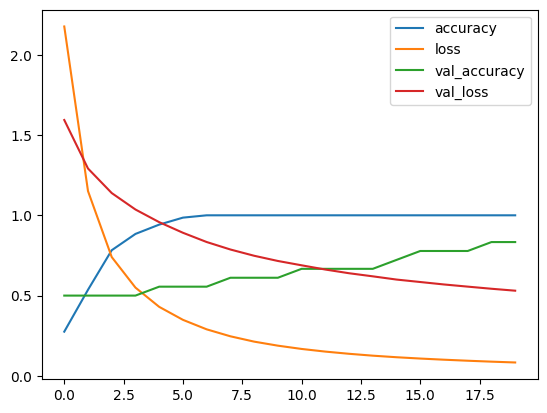

In [28]:
pd.DataFrame(history.history).plot()

In [29]:
#entrenam més epochs
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0789 - val_accuracy: 0.8333 - val_loss: 0.5205
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0747 - val_accuracy: 0.8333 - val_loss: 0.5103
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0709 - val_accuracy: 0.8333 - val_loss: 0.4998
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0674 - val_accuracy: 0.8333 - val_loss: 0.4899
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0643 - val_accuracy: 0.8333 - val_loss: 0.4808
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0614 - val_accuracy: 0.8333 - val_loss: 0.4721
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0588 - val_accuracy: 0.8333 - val_loss: 0.4645
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0563 - val_accuracy: 0.8333 - val_loss: 0.4566


<Axes: >

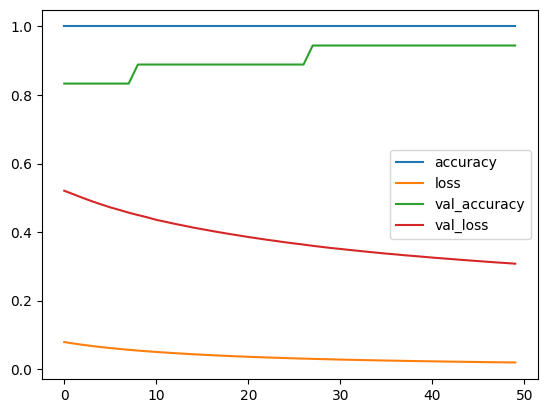

In [30]:
pd.DataFrame(history.history).plot()

In [31]:
#entrenam més epochs. A veure si feim overfitting
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0190 - val_accuracy: 0.9444 - val_loss: 0.3058
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 1.0000 - loss: 0.0187 - val_accuracy: 0.9444 - val_loss: 0.3041
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0184 - val_accuracy: 0.9444 - val_loss: 0.3026
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0181 - val_accuracy: 0.9444 - val_loss: 0.3008
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0178 - val_accuracy: 0.9444 - val_loss: 0.2993
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0175 - val_accuracy: 0.9444 - val_loss: 0.2977
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0173 - val_accuracy: 0.9444 - val_loss: 0.2961
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - loss: 0.0170 - val_accuracy: 0.9444 - val_loss:

<Axes: >

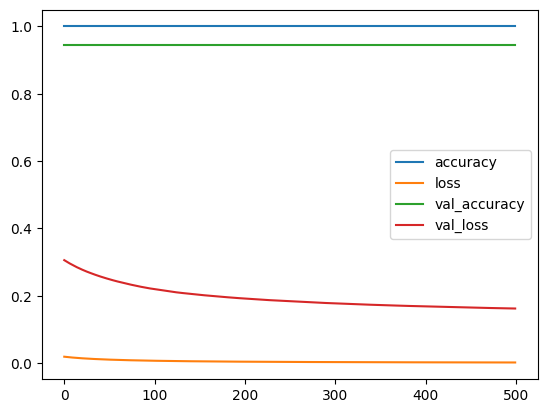

In [32]:
pd.DataFrame(history.history).plot()

In [33]:
model.evaluate(X_test, y_test) #ojo, prova per classe, real hem de tirar contra test al final

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8837 - loss: 0.4357


[0.4356725811958313, 0.8837209343910217]

In [43]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(54675,)), 
    keras.layers.Dense(units=100, activation='relu'), 
    keras.layers.Dense(units=100, activation='relu'),
    keras.layers.Dense(units=100, activation='relu'), 
    keras.layers.Dense(units=100, activation='relu'), 
    keras.layers.Dense(units=100, activation='relu'), 
    keras.layers.Dense(units=5, activation='softmax') 
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 100)            │     5,467,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,508,505 (21.01 MB)

 Trainable params: 5,508,505 (21.01 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
#compilar
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='rmsprop', #rmsprop o adam són dels millors per defecte. Amb text no configuram learning_rate
    metrics=['accuracy'] 
)

In [49]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.5217 - loss: 4.9550 - val_accuracy: 0.5556 - val_loss: 8.9036
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6522 - loss: 6.6400 - val_accuracy: 1.0000 - val_loss: 0.0097
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7391 - loss: 2.4304 - val_accuracy: 0.8889 - val_loss: 0.1526
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9130 - loss: 0.5776 - val_accuracy: 0.7778 - val_loss: 1.3996
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9855 - loss: 0.0201 - val_accuracy: 0.8333 - val_loss: 0.6027
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 6.4093e-04 - val_accuracy: 0.8333 - val_loss: 0.6088
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 5.0593e-04 - val_accuracy: 0.8333 - val_loss: 0.6131
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 4.1266e-04 - val_accuracy: 0.8333 - val_

<Axes: >

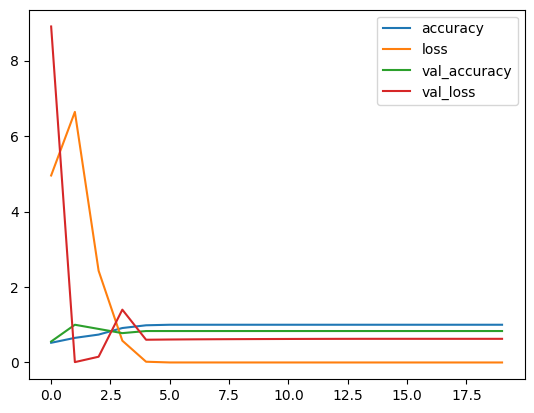

In [50]:
pd.DataFrame(history.history).plot()

Ràpidament hem fet overfitting ja que la xarxa és bastant profunda per les dades que tenim i amés el learning rate és per defecte.

Com ho prevenim? Com podem tornar enrera?

# Callbacks

Funcions que es criden després de cada epoch

* **EarlyStopping**: verifica que el loss de validació sigui menor que a l'epoch anterior. Si no és així aborta l'entrenament i torna els paràmetres (pesos i biaxos) al punt anterior a fer overfitting.
* **ModelCheckPoint**: Desa la xarxa neuronal a un fitxer.

In [51]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)), 
    keras.layers.Dense(units=20, activation='relu'), 
    keras.layers.Dense(units=20, activation='relu'),
    keras.layers.Dense(units=5, activation='softmax') 
])

base_learning_rate = 0.0001
optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy'] 
)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, #nombre de epochs que permet fer abans de confirmar overfitting
                                                 restore_best_weights=True) #desfà canvis d'overfitting
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500, #fora por, ja aturarà en fer overfitting
    callbacks=[early_stopping_cb] #llista de callbacks
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.3623 - loss: 1.3831 - val_accuracy: 0.8333 - val_loss: 0.4027
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8261 - loss: 0.5316 - val_accuracy: 0.8889 - val_loss: 0.2552
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.1250 - val_accuracy: 0.9444 - val_loss: 0.1667
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0461 - val_accuracy: 0.9444 - val_loss: 0.1600
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0284 - val_accuracy: 0.9444 - val_loss: 0.1510
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0218 - val_accuracy: 0.9444 - val_loss: 0.1450
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0172 - val_accuracy: 0.9444 - val_loss: 0.1385
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0142 - val_accuracy: 0.9444 - val_loss:

In [57]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)), 
    keras.layers.Dense(units=20, activation='relu'), 
    keras.layers.Dense(units=20, activation='relu'),
    keras.layers.Dense(units=5, activation='softmax') 
])

base_learning_rate = 0.0001
optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy'] 
)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, #nombre de epochs que permet fer abans de confirmar overfitting
                                                 restore_best_weights=True) #desfà canvis d'overfitting

model_ckeckpoint_cb = keras.callbacks.ModelCheckpoint('brain_cancer.keras', #ruta fitxer
                                                 save_best_only=True, #sols guarda fitxer si millora
                                                 save_freq='epoch') 
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    callbacks=[early_stopping_cb, model_ckeckpoint_cb] #llista de callbacks
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.2899 - loss: 2.1867 - val_accuracy: 0.4444 - val_loss: 1.1105
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6667 - loss: 0.8053 - val_accuracy: 0.7222 - val_loss: 0.5898
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8696 - loss: 0.3193 - val_accuracy: 0.7222 - val_loss: 0.5476
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9130 - loss: 0.1843 - val_accuracy: 0.7778 - val_loss: 0.4488
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9855 - loss: 0.1311 - val_accuracy: 0.7778 - val_loss: 0.4745
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9565 - loss: 0.1088 - val_accuracy: 0.7778 - val_loss: 0.3939
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9855 - loss: 0.0866 - val_accuracy: 0.7778 - val_loss: 0.4699
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9855 - loss: 0.0763 - val_accuracy: 0.7778 - val_loss:

In [58]:
#avaluam
acc_test = model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8140 - loss: 0.4803


In [59]:
#carregam model del fitxer
model_fitxer = keras.models.load_model('brain_cancer.keras') #pesa aprox 8MB
model_fitxer

<Sequential name=sequential_5, built=True>

In [63]:
model.layers

[<Dense name=dense_21, built=True>,
 <Dense name=dense_22, built=True>,
 <Dense name=dense_23, built=True>]

In [64]:
acc_test_fitxer = model_fitxer.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8140 - loss: 0.4803 


In [65]:
model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)), 
    keras.layers.Dense(units=1000, activation='relu'), #provam amb xarxa més ampla
    keras.layers.Dense(units=1000, activation='relu'), 
    keras.layers.Dense(units=1000, activation='relu'), 
    keras.layers.Dense(units=5, activation='softmax') 
])

base_learning_rate = 0.0001
optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy'] 
)

early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, #nombre de epochs que permet fer abans de confirmar overfitting
                                                 restore_best_weights=True) #desfà canvis d'overfitting

model_ckeckpoint_cb = keras.callbacks.ModelCheckpoint('brain_cancer.keras', #ruta fitxer
                                                 save_best_only=True, #sols guarda fitxer si millora
                                                 save_freq='epoch') 
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    callbacks=[early_stopping_cb, model_ckeckpoint_cb] #llista de callbacks
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 768ms/step - accuracy: 0.4058 - loss: 1.9983 - val_accuracy: 0.9444 - val_loss: 0.2558
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 867ms/step - accuracy: 0.8696 - loss: 1.5736 - val_accuracy: 0.9444 - val_loss: 0.1217
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 717ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.9444 - val_loss: 0.1017
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 311ms/step - accuracy: 1.0000 - loss: 6.6665e-04 - val_accuracy: 0.9444 - val_loss: 0.1023
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 296ms/step - accuracy: 1.0000 - loss: 5.4129e-04 - val_accuracy: 0.9444 - val_loss: 0.1031
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 1.0000 - loss: 4.5258e-04 - val_accuracy: 0.9444 - val_loss: 0.1038


In [66]:
model.summary() #pesa 432.46MB amb 113 milions de params

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 1000)           │    54,676,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 5)              │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,366,012 (432.46 MB)

 Trainable params: 56,683,005 (216.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56,683,007 (216.23 MB)

# Transfer learning i fine tuning

* Partim d'un model preentrenat.
* Carregam el model.
* Eliminam algunes capes (les que no segueixen l'objectiu que cercam).
* "Congelam" capes antigues.
* Cream un model nou, amb capes antigues congelades i noves sense entrenar.
* Entrenam el model uns pocs epochs.
* Descongelam capes antigues
* Entrenam tot el nou model complet baixant el learning rate.

In [18]:
base_model = keras.models.load_model('brain_cancer.keras')
base_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 1000)           │    54,676,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 5)              │         5,005 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,366,012 (432.46 MB)

 Trainable params: 56,683,005 (216.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 56,683,007 (216.23 MB)

In [19]:
base_model.layers

[<Dense name=dense_24, built=True>,
 <Dense name=dense_25, built=True>,
 <Dense name=dense_26, built=True>,
 <Dense name=dense_27, built=True>]

In [27]:
input_layer = base_model.layers[0].input #entrada de primera capa -> capa de input
input_layer

<KerasTensor shape=(None, 54675), dtype=float32, sparse=False, ragged=False, name=input_layer_6>

In [29]:
base_model.layers[-1] #darrera capa

<Dense name=dense_27, built=True>

In [30]:
base_model.layers[-1].input #entrada de darrera capa

<KerasTensor shape=(None, 1000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_8>

In [31]:
base_model.layers[-2] #darrera capa oculta

<Dense name=dense_26, built=True>

In [32]:
base_model.layers[-2].output #sortida de darrera capa oculta.

<KerasTensor shape=(None, 1000), dtype=float32, sparse=False, ragged=False, name=keras_tensor_5>

In [34]:
from keras.models import Model

new_model = Model(inputs=[input_layer],
                 outputs=[base_model.layers[-2].output])
new_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 54675)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1000)           │    54,676,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1000)           │     1,001,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,678,000 (216.21 MB)

 Trainable params: 56,678,000 (216.21 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
new_model.layers[-1].trainable #capa és entrenable = no està congelada

True

In [38]:
#congelam tota la xarxa anterior
for layer in new_model.layers:
    layer.trainable = False

In [41]:
new_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 54675)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1000)           │    54,676,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1000)           │     1,001,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,678,000 (216.21 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 56,678,000 (216.21 MB)

In [46]:
#farem wide and deep
from keras.layers import Concatenate

concat_layer = Concatenate()([new_model.layers[-1].output, input_layer]) #No és un paràmetre, és API Funcional

In [47]:
output_layer = keras.layers.Dense(units=5, activation='softmax', name='densa_final')(concat_layer)
final_model = keras.models.Model(inputs=[input_layer], outputs=[output_layer])
final_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 54675)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1000)      │ 54,676,000 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 1000)      │  1,001,000 │ dense_24[2][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1000)      │  1,001,000 │ dense_25[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 55675)     │          0 │ dense_26[0][0],   │
│ (Concatenate)       │                   │            │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densa_final (Dense) │ (None, 5)         │    278,380 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,956,380 (217.27 MB)

 Trainable params: 278,380 (1.06 MB)

 Non-trainable params: 56,678,000 (216.21 MB)

In [48]:
base_learning_rate = 0.001
optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate)

final_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

In [49]:
#basura, la darrera capa és aleatòria i destrueix tot
final_model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1860 - loss: 2.0695 


[2.0695269107818604, 0.1860465109348297]

In [50]:
#entrenam uns pocs epochs per a no destruir coneixement anterior
history = final_model.fit(X_train, y_train, epochs=2, #pocs epochs, 2 o 3 solen bastar
                         validation_split=0.2)

Epoch 1/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4928 - loss: 10.7504 - val_accuracy: 0.7222 - val_loss: 7.2254
Epoch 2/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8841 - loss: 2.9420 - val_accuracy: 0.8889 - val_loss: 1.5457


In [51]:
#encara no hem fet fine tuning, però ja no donarà basura

In [53]:
#FINE TUNING

base_learning_rate = 0.001 / 10 #learning rate 10 vegades menor
optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate)

#descongelam
#IMPORTANT RECOMPILAR
for layer in final_model.layers:
    layer.trainable = True
    
final_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

final_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 54675)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 1000)      │ 54,676,000 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 1000)      │  1,001,000 │ dense_24[2][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1000)      │  1,001,000 │ dense_25[1][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 55675)     │          0 │ dense_26[0][0],   │
│ (Concatenate)       │                   │            │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densa_final (Dense) │ (None, 5)         │    278,380 │ concatenate_1[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 56,956,380 (217.27 MB)

 Trainable params: 56,956,380 (217.27 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=5, 
                                                 restore_best_weights=True) 

model_ckeckpoint_cb = keras.callbacks.ModelCheckpoint('brain_cancer_transfer_learning.keras', 
                                                 save_best_only=True, 
                                                 save_freq='epoch') 
history = final_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    callbacks=[early_stopping_cb, model_ckeckpoint_cb]
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 749ms/step - accuracy: 0.9710 - loss: 0.1556 - val_accuracy: 0.8889 - val_loss: 1.1621
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 761ms/step - accuracy: 1.0000 - loss: 1.8226e-06 - val_accuracy: 0.8889 - val_loss: 1.1621
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 897ms/step - accuracy: 1.0000 - loss: 1.6619e-06 - val_accuracy: 0.8889 - val_loss: 1.1621
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 752ms/step - accuracy: 1.0000 - loss: 1.5272e-06 - val_accuracy: 0.8889 - val_loss: 1.1620
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 979ms/step - accuracy: 1.0000 - loss: 1.4114e-06 - val_accuracy: 0.8889 - val_loss: 1.1620
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 1.0000 - loss: 1.3112e-06 - val_accuracy: 0.8889 - val_loss: 1.1620
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 1.0000 - loss: 1.2214e-06 - val_accuracy: 0.8889 - val_loss: 1.1619
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 1.0000 - loss: 1.1437e-06 - val_a

# Dropout Layer

Dropout dona la possibilitat de desactivar neurones durant la fase d'aprenentatge (**NO EN MODE INFERÈNCIA**)

In [18]:
from keras.layers import Input, Dense, Dropout

dropout_rate = 0.4 #sol esser entre un 10% i un 50% depenent del problema

model = keras.models.Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(100, activation='relu'),
    Dropout(dropout_rate),
    Dense(100, activation='relu'),
    Dropout(dropout_rate),
    Dense(5, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │     5,467,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,478,205 (20.90 MB)

 Trainable params: 5,478,205 (20.90 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'] 
)

In [20]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                 restore_best_weights=True)
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    callbacks=[early_stopping_cb]
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.2609 - loss: 8.9708 - val_accuracy: 0.8889 - val_loss: 0.5417
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5797 - loss: 8.9436 - val_accuracy: 0.8333 - val_loss: 1.4424
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.6087 - loss: 12.5976 - val_accuracy: 0.9444 - val_loss: 0.3557
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6522 - loss: 11.3955 - val_accuracy: 0.8889 - val_loss: 1.3899
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7536 - loss: 9.1712 - val_accuracy: 0.8333 - val_loss: 5.5115


In [21]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8140 - loss: 5.3391


[5.339112281799316, 0.8139534592628479]

In [22]:
from keras.layers import Input, Dense, Dropout

dropout_rate = 0.1 #sol esser entre un 10% i un 50% depenent del problema

model = keras.models.Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(100, activation='relu'),
    Dropout(dropout_rate),
    Dense(100, activation='relu'),
    Dropout(dropout_rate),
    Dense(5, activation='softmax')
])
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'] 
)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                 restore_best_weights=True)
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    callbacks=[early_stopping_cb]
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.3333 - loss: 3.9123 - val_accuracy: 0.8889 - val_loss: 1.1100
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8116 - loss: 3.1281 - val_accuracy: 0.8333 - val_loss: 4.6158
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8406 - loss: 5.0947 - val_accuracy: 0.7778 - val_loss: 5.2200


In [23]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8372 - loss: 5.2164


[5.216377258300781, 0.8372092843055725]

In [24]:
from keras.layers import Input, Dense, Dropout

dropout_rate = 0.9 #sol esser entre un 10% i un 50% depenent del problema

model = keras.models.Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(100, activation='relu'),
    Dropout(dropout_rate),
    Dense(100, activation='relu'),
    Dropout(dropout_rate),
    Dense(5, activation='softmax')
])
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'] 
)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                 restore_best_weights=True)
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=500,
    callbacks=[early_stopping_cb]
)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.1449 - loss: 44.1844 - val_accuracy: 0.2778 - val_loss: 12.3170
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2464 - loss: 148.1257 - val_accuracy: 0.5556 - val_loss: 9.9993
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2609 - loss: 159.5215 - val_accuracy: 0.6667 - val_loss: 10.3697
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.2464 - loss: 219.6865 - val_accuracy: 0.6667 - val_loss: 8.8010
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3043 - loss: 237.5468 - val_accuracy: 0.6667 - val_loss: 10.7605
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2174 - loss: 302.0198 - val_accuracy: 0.6111 - val_loss: 12.1737


In [25]:
model.evaluate(X_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4186 - loss: 16.4526


[16.45258903503418, 0.41860464215278625]